ML PROJECT JAN-31

'UBER PICKUP TIME PREDICTION'

In [ ]:
#1.Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
#2.Load The Dataset

df = pd.read_csv("/content/uber_processed_data_final.csv")
df.head()


,fare_amount,distance_km,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour
0,7.5,1.683,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19
1,7.7,2.458,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20
2,12.9,5.036,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21
3,5.3,1.662,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8
4,16.0,4.475,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17


In [ ]:
#3.Basic Dataset Info

df.shape

(159315, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159315 entries, 0 to 159314
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fare_amount        159315 non-null  float64
 1   distance_km        159315 non-null  float64
 2   pickup_longitude   159315 non-null  float64
 3   pickup_latitude    159315 non-null  float64
 4   dropoff_longitude  159315 non-null  float64
 5   dropoff_latitude   159315 non-null  float64
 6   passenger_count    159315 non-null  int64  
 7   year               159315 non-null  int64  
 8   month              159315 non-null  int64  
 9   day                159315 non-null  int64  
 10  hour               159315 non-null  int64  
dtypes: float64(6), int64(5)
memory usage: 13.4 MB


In [ ]:
df.describe()

,fare_amount,distance_km,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour
count,159315.000000,159315.000000,159315.000000,159315.000000,159315.000000,159315.000000,159315.000000,159315.000000,159315.000000,159315.000000,159315.000000
mean,8.158718,2.080759,-73.918122,40.693041,-73.917257,40.693115,1.687230,2011.727941,6.265072,15.699168,13.634071
std,3.344993,1.177093,2.624597,2.564688,2.624580,2.564707,1.305366,1.864551,3.449754,8.679508,6.361384
min,2.500000,0.000000,-75.387785,-74.009697,-75.375315,-74.009857,1.000000,2009.000000,1.000000,1.000000,0.000000
25%,5.700000,1.154000,-73.992268,40.738276,-73.991788,40.738285,1.000000,2010.000000,3.000000,8.000000,9.000000
50%,7.500000,1.834000,-73.982392,40.753573,-73.981640,40.753957,1.000000,2012.000000,6.000000,16.000000,14.000000
75%,10.000000,2.822000,-73.970572,40.766742,-73.969756,40.766897,2.000000,2013.000000,9.000000,23.000000,19.000000
max,22.100000,5.147000,40.808425,45.031653,40.831932,45.031598,6.000000,2015.000000,12.000000,31.000000,23.000000


In [ ]:
#4.Check Missing Values

df.isnull().sum()

,0
fare_amount,0
distance_km,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0
year,0
month,0
day,0


In [ ]:
df=df.dropna()

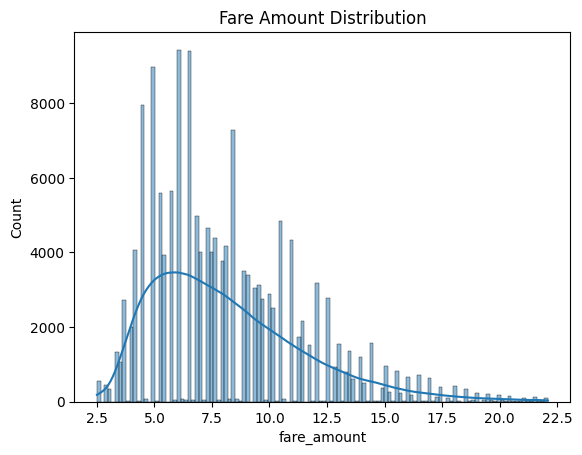

In [ ]:
#5.Exploratory Data Analysis(EDA)
#Distrubution Of Target Variable

plt.figure()
sns.histplot(df['fare_amount'], kde=True)
plt.title("Fare Amount Distribution")
plt.show()


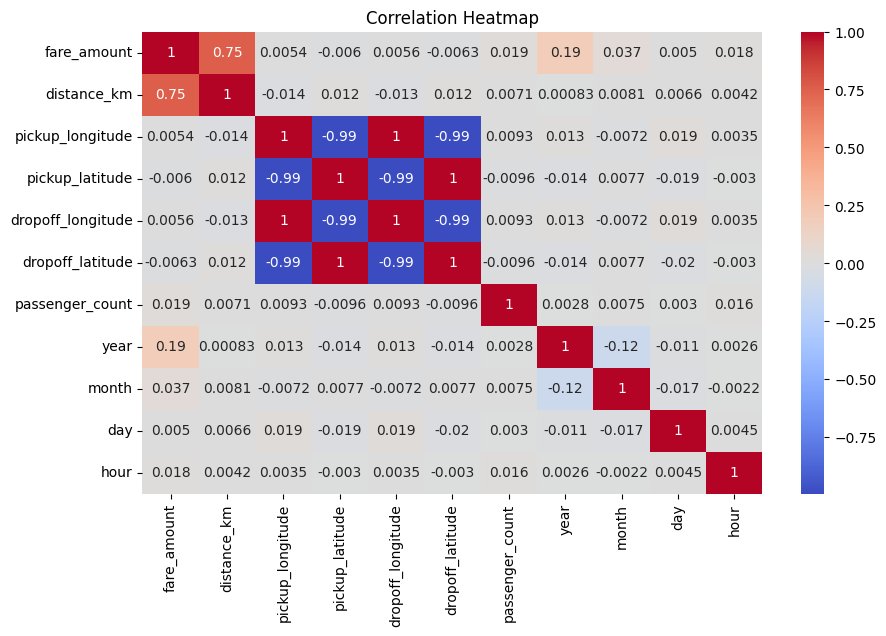

In [ ]:
#Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


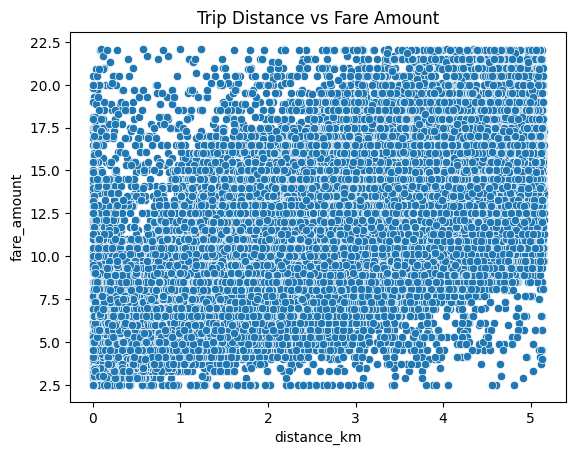

In [ ]:
#Relationship Between Distance&Fare

plt.figure()
sns.scatterplot(x='distance_km', y='fare_amount', data=df)
plt.title("Trip Distance vs Fare Amount")
plt.show()

In [ ]:
#Feature Selection

X = df.drop('fare_amount', axis=1)
y = df['fare_amount']


In [ ]:
#Train-Test-Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
#Train Regression Model

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
#Predictions

y_pred = model.predict(X_test)


In [ ]:
#Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)


MAE : 1.4717968348960284
MSE : 4.255361824027186
RMSE: 2.06285283625061
R2  : 0.6155968775648835


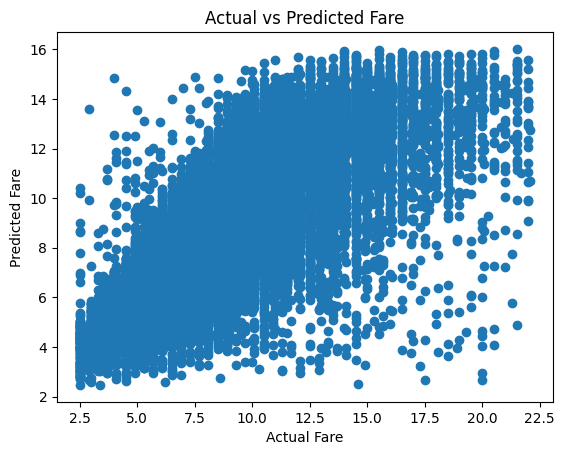

In [ ]:
#Actual Predicted Plot

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.show()


In [ ]:
#Model Coefficients

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coeff_df


,Feature,Coefficient
0,distance_km,2.135120
1,pickup_longitude,-1.656597
2,pickup_latitude,8.661578
3,dropoff_longitude,1.723587
4,dropoff_latitude,-8.608659
5,passenger_count,0.034745
6,year,0.343662
7,month,0.051225
8,day,0.001008
9,hour,0.007661


In [ ]:
print("Project Completed Successfully!")

Project Completed Successfully!
